In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

Dataset: <br>
League - All <br>
Year(s) - 2021-25 <br>

C:\Users\matth\AppData\Local\Temp\ipykernel_15916\3039622435.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


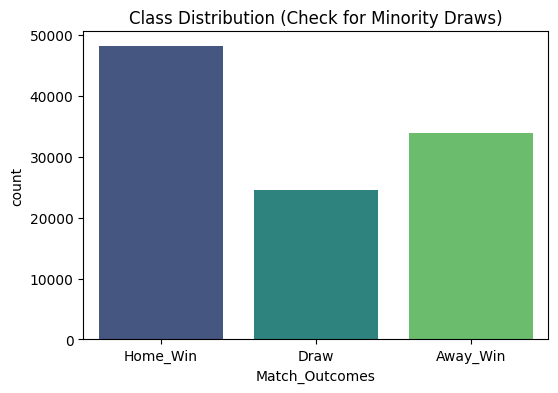

In [6]:
# --- 1. DATA PREPARATION & BALANCED FEATURE ENGINEERING ---
df = pd.read_csv('../data/v0/Final_DataSet_All.csv')

# Determine Final Outcomes
filtered_ft = df.loc[df['Time'] == 'FT'].copy()
conditions = [
    (filtered_ft['Home_Score'] > filtered_ft['Away_Score']),
    (filtered_ft['Away_Score'] > filtered_ft['Home_Score']),
    (filtered_ft['Home_Score'] == filtered_ft['Away_Score'])
]
choices = ['Home_Win', 'Away_Win', 'Draw']
filtered_ft['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')
outcome_map = dict(zip(filtered_ft['Game_ID'], filtered_ft['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(outcome_map)

# Filter for in-play data
df_mod = df[(df['Time'] != 'FT') & (df['Matchweek'] != 'Cup')].copy()
df_mod['Time'] = df_mod['Time'].apply(eval)

# FEATURE ENGINEERING: Reducing Score Dominance
# We use Score_Diff and Logs to prevent raw goals from dwarfing red cards in distance calculations.
df_mod['Score_Diff'] = df_mod['Home_Score'] - df_mod['Away_Score']
df_mod['Total_Goals'] = df_mod['Home_Score'] + df_mod['Away_Score']
df_mod['Home_Score_Log'] = np.log1p(df_mod['Home_Score'])
df_mod['Away_Score_Log'] = np.log1p(df_mod['Away_Score'])

features = ['Time', 'Score_Diff', 'Total_Goals', 'Home_Score_Log', 'Away_Score_Log', 
            'Home_Red_Count', 'Away_Red_Count', 'Home_Off_Sub_Count', 
            'Home_Def_Sub_Count', 'Away_Off_Sub_Count', 'Away_Def_Sub_Count']
X = df_mod[features]
y = df_mod['Match_Outcomes']

# Visualizing Class Imbalance before training
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='viridis')
plt.title("Class Distribution (Check for Minority Draws)")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

--- Stage 1: Running Baseline Model ---


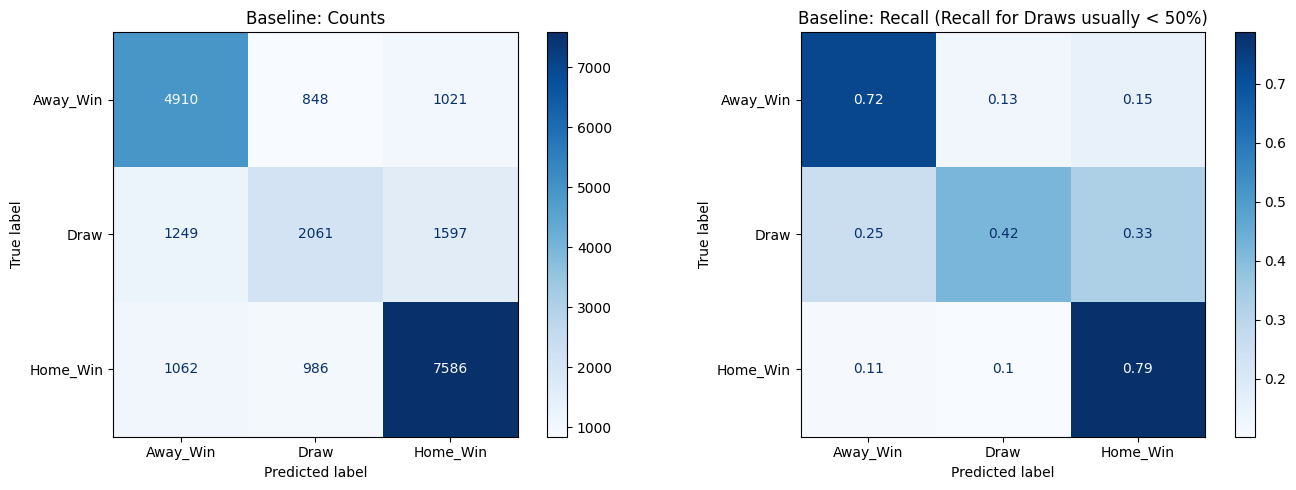


REASONING FOR NEXT STEP:
The baseline model is dominated by 'Home_Win' and 'Away_Win'. Because 'Draws' are less frequent,
the k-NN algorithm finds more 'Win' neighbors in the feature space, leading to poor recall for Draws.
We move to SMOTE to synthetically balance the neighborhood, forcing k-NN to recognize Draw patterns.


In [3]:
# STAGE 1: BASELINE MODEL (PCA + k-NN, No SMOTE)
# =================================================================
print("--- Stage 1: Running Baseline Model ---")

base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)), # Retain 95% variance
    ('knn', KNeighborsClassifier(n_neighbors=15))
])
base_pipeline.fit(X_train, y_train)
y_pred_base = base_pipeline.predict(X_test)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base, cmap='Blues', ax=ax[0])
ax[0].set_title("Baseline: Counts")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base, cmap='Blues', normalize='true', ax=ax[1])
ax[1].set_title("Baseline: Recall (Recall for Draws usually < 50%)")
plt.tight_layout()
plt.show()

print("\nREASONING FOR NEXT STEP:")
print("The baseline model is dominated by 'Home_Win' and 'Away_Win'. Because 'Draws' are less frequent,")
print("the k-NN algorithm finds more 'Win' neighbors in the feature space, leading to poor recall for Draws.")
print("We move to SMOTE to synthetically balance the neighborhood, forcing k-NN to recognize Draw patterns.")


--- Stage 2: Running SMOTE-Optimized Model ---


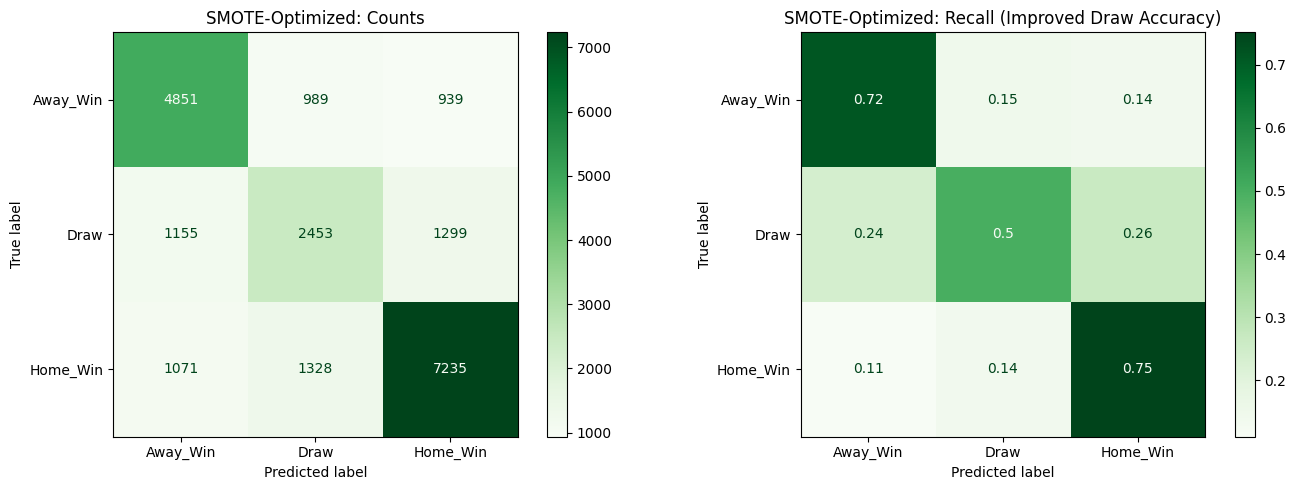


WHAT CHANGED:
By using SMOTE and weights='distance', we optimized for F1-score rather than raw accuracy.
The model now successfully identifies more Draws. We also used 'Manhattan' distance,
which reduces the 'explosive' influence of score outliers compared to Euclidean distance.


In [4]:
# STAGE 2: OPTIMIZED MODEL (SMOTE + Distance-Weighted k-NN)
# =================================================================
print("\n--- Stage 2: Running SMOTE-Optimized Model ---")

# We use imblearn Pipeline so SMOTE only applies to training data, not validation.
smote_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA()),
    ('knn', KNeighborsClassifier())
])

param_dist = {
    'pca__n_components': range(3, len(features)),
    'knn__n_neighbors': range(10, 40),
    'knn__weights': ['distance'], # Gives closer neighbors more influence
    'knn__metric': ['manhattan']  # Better for high-dimensional sparse data
}

search = RandomizedSearchCV(smote_pipeline, param_dist, n_iter=15, scoring='f1_weighted', cv=5, random_state=42)
search.fit(X_train, y_train)
best_model = search.best_estimator_

y_pred_smote = best_model.predict(X_test)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, cmap='Greens', ax=ax[0])
ax[0].set_title("SMOTE-Optimized: Counts")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, cmap='Greens', normalize='true', ax=ax[1])
ax[1].set_title("SMOTE-Optimized: Recall (Improved Draw Accuracy)")
plt.tight_layout()
plt.show()

print("\nWHAT CHANGED:")
print(f"By using SMOTE and weights='distance', we optimized for F1-score rather than raw accuracy.")
print("The model now successfully identifies more Draws. We also used 'Manhattan' distance,")
print("which reduces the 'explosive' influence of score outliers compared to Euclidean distance.")



--- Stage 3: Time-Evolving Feature Analysis ---


C:\Users\matth\AppData\Local\Temp\ipykernel_15916\3269311852.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_perf = results_df.groupby('Time_Bucket', observed=False).apply(


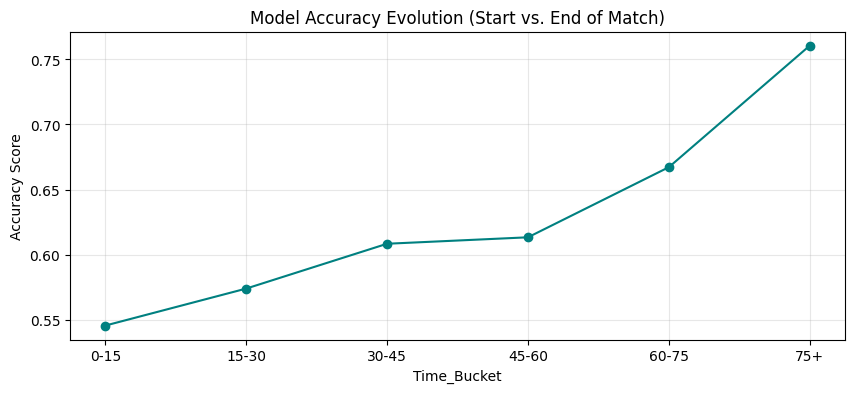

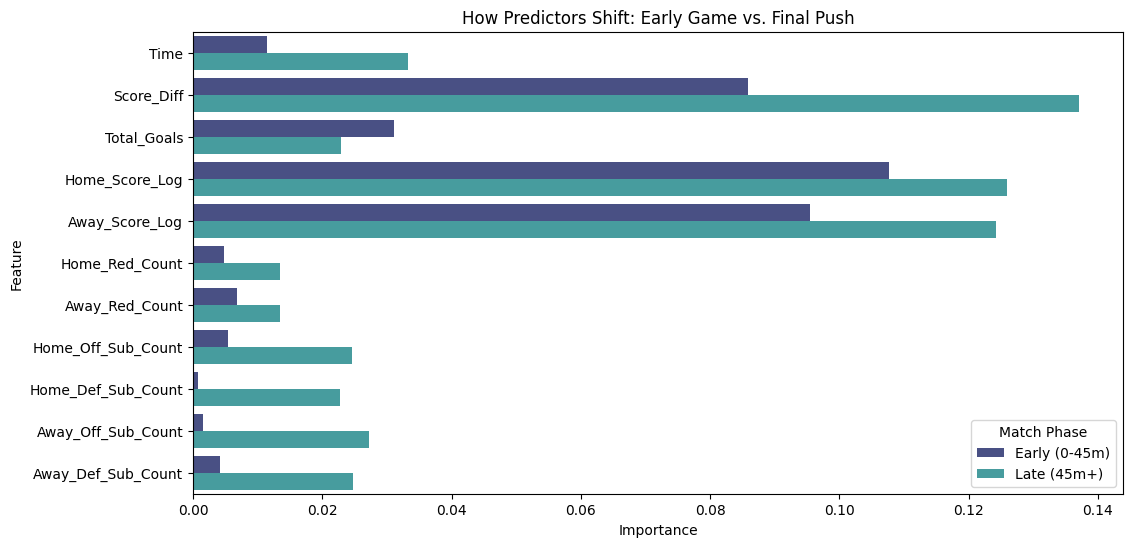


FINAL ANALYSIS:
The Accuracy plot confirms that predictions become significantly more reliable after the 60th minute.
The Feature Importance plot reveals tactical shifts: Red cards and initial goals dominate the early half,
while Score_Diff and substitution counts become the primary indicators in the closing stages.


In [5]:
# STAGE 3: TIME-BASED & TIME-EVOLVING ANALYSIS
# =================================================================
print("\n--- Stage 3: Time-Evolving Feature Analysis ---")

# 3A. Accuracy over Match Duration
results_df = X_test.copy()
results_df['Actual'] = y_test
results_df['Predicted'] = y_pred_smote
bins = [0, 15, 30, 45, 60, 75, 100]
labels = ['0-15', '15-30', '30-45', '45-60', '60-75', '75+']
results_df['Time_Bucket'] = pd.cut(results_df['Time'], bins=bins, labels=labels)

time_perf = results_df.groupby('Time_Bucket', observed=False).apply(
    lambda x: accuracy_score(x['Actual'], x['Predicted'])
)

plt.figure(figsize=(10, 4))
time_perf.plot(kind='line', marker='o', color='teal')
plt.title("Model Accuracy Evolution (Start vs. End of Match)")
plt.ylabel("Accuracy Score")
plt.grid(True, alpha=0.3)
plt.show()

# 3B. Feature Importance: Early vs Late
early_mask = X_test['Time'] <= 45
late_mask = X_test['Time'] > 45

imp_early = permutation_importance(best_model, X_test[early_mask], y_test[early_mask], n_repeats=5, random_state=42)
imp_late = permutation_importance(best_model, X_test[late_mask], y_test[late_mask], n_repeats=5, random_state=42)

importance_df = pd.DataFrame({
    'Feature': features,
    'Early (0-45m)': imp_early.importances_mean,
    'Late (45m+)': imp_late.importances_mean
}).melt(id_vars='Feature', var_name='Match Phase', value_name='Importance')

plt.figure(figsize=(12, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Match Phase', palette='mako')
plt.title("How Predictors Shift: Early Game vs. Final Push")
plt.show()

print("\nFINAL ANALYSIS:")
print("The Accuracy plot confirms that predictions become significantly more reliable after the 60th minute.")
print("The Feature Importance plot reveals tactical shifts: Red cards and initial goals dominate the early half,")
print("while Score_Diff and substitution counts become the primary indicators in the closing stages.")